In [ ]:
import pandas as pd
import numpy as np

features_df = pd.read_csv("features.csv")
metadata_df = pd.read_csv("metadata.csv")

print("FEATURES")
print("Shape:", features_df.shape)
print("Columns:")
print(features_df.columns.tolist())

print("\nMETADATA")
print("Shape:", metadata_df.shape)
print("Columns:")
print(metadata_df.columns.tolist())

print("\nFEATURES PREVIEW")
display(features_df.head())

print("\nMETADATA PREVIEW")
display(metadata_df.head())

FEATURES
Shape: (100850, 17)
Columns:
['packets_per_second', 'bytes_per_second', 'mean_packet_size', 'std_packet_size', 'syn_ratio', 'ack_ratio', 'rst_ratio', 'fin_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_src_ports', 'unique_dst_ports', 'connection_rate', 'flow_duration', 'label', 'label_name', 'window_id']

METADATA
Shape: (100100, 10)
Columns:
['window_id', 'window_start', 'window_end', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'label', 'label_name']

FEATURES PREVIEW


,packets_per_second,bytes_per_second,mean_packet_size,std_packet_size,syn_ratio,ack_ratio,rst_ratio,fin_ratio,unique_src_ips,unique_dst_ips,unique_src_ports,unique_dst_ports,connection_rate,flow_duration,label,label_name,window_id
0,1.000000,70.000000,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.000000,0.000000,0.0,Normal,0.0
1,1.000000,70.000000,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.000000,0.000000,0.0,Normal,0.0
2,1.000000,70.000000,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.000000,0.000000,0.0,Normal,0.0
3,1.000000,70.000000,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.000000,0.000000,0.0,Normal,0.0
4,1.142882,80.001711,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.142882,3.499925,0.0,Normal,1.0



METADATA PREVIEW


,window_id,window_start,window_end,src_ip,dst_ip,src_port,dst_port,protocol,label,label_name
0,0,1.457625e+09,1.457625e+09,59.166.0.0,10.40.85.31,60294.0,80.0,TCP,0.0,Normal
1,0,1.457625e+09,1.457625e+09,59.166.0.3,10.40.85.31,22311.0,1024.0,TCP,0.0,Normal
2,0,1.457625e+09,1.457625e+09,59.166.0.4,10.40.85.31,63239.0,27322.0,TCP,0.0,Normal
3,0,1.457625e+09,1.457625e+09,59.166.0.2,10.40.85.31,37241.0,23962.0,TCP,0.0,Normal
4,1,1.457625e+09,1.457625e+09,59.166.0.5,10.40.85.31,17808.0,80.0,TCP,0.0,Normal


In [2]:
print("Potential label columns in FEATURES:")

for col in features_df.columns:
    if any(x in col.lower() for x in ["label", "attack", "class", "type"]):
        print("  ", col)

print("\nPotential label columns in METADATA:")

for col in metadata_df.columns:
    if any(x in col.lower() for x in ["label", "attack", "class", "type"]):
        print("  ", col)

Potential label columns in FEATURES:
   label
   label_name

Potential label columns in METADATA:
   label
   label_name


In [3]:
for df_name, df in [
    ("features", features_df),
    ("metadata", metadata_df)
]:
    print(f"\n===== {df_name.upper()} =====")

    for col in df.columns:
        if any(x in col.lower() for x in ["label", "attack", "class", "type"]):
            print(f"\nColumn: {col}")
            print(df[col].value_counts(dropna=False).head(30))


===== FEATURES =====

Column: label
label
0.0    100504
1.0       345
NaN         1
Name: count, dtype: int64

Column: label_name
label_name
Normal               100504
Exploits                257
Denial of Service        38
Shellcode                37
Worms                     7
Generic                   6
NaN                       1
Name: count, dtype: int64

===== METADATA =====

Column: label
label
0.0    99228
NaN      616
1.0      256
Name: count, dtype: int64

Column: label_name
label_name
Normal               99228
NaN                    616
Exploits               221
Denial of Service       29
Generic                  6
Name: count, dtype: int64


In [4]:
FEATURE_NAMES = [
    "packets_per_second",
    "bytes_per_second",
    "mean_packet_size",
    "std_packet_size",
    "syn_ratio",
    "ack_ratio",
    "rst_ratio",
    "fin_ratio",
    "unique_src_ips",
    "unique_dst_ips",
    "unique_src_ports",
    "unique_dst_ports",
    "connection_rate",
    "flow_duration",
]

missing_features = [
    feature
    for feature in FEATURE_NAMES
    if feature not in features_df.columns
]

if missing_features:
    print("Missing features:")
    print(missing_features)
    raise ValueError("Feature schema does not match the expected 14 features.")

print("All 14 features found.")

All 14 features found.


In [5]:
print("Feature columns:")
print(features_df.columns.tolist())

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Feature columns:
['packets_per_second', 'bytes_per_second', 'mean_packet_size', 'std_packet_size', 'syn_ratio', 'ack_ratio', 'rst_ratio', 'fin_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_src_ports', 'unique_dst_ports', 'connection_rate', 'flow_duration', 'label', 'label_name', 'window_id']

Metadata columns:
['window_id', 'window_start', 'window_end', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'label', 'label_name']


In [6]:
dataset = features_df.copy()

In [7]:
# Automatically find a common key
common_columns = list(
    set(features_df.columns).intersection(
        set(metadata_df.columns)
    )
)

print("Common columns:")
print(common_columns)

Common columns:
['window_id', 'label_name', 'label']


In [8]:
dataset = features_df.merge(
    metadata_df,
    on="window_id",
    how="left",
    suffixes=("", "_metadata")
)

print("Merged shape:", dataset.shape)
display(dataset.head())

Merged shape: (1835305, 26)


,packets_per_second,bytes_per_second,mean_packet_size,std_packet_size,syn_ratio,ack_ratio,rst_ratio,fin_ratio,unique_src_ips,unique_dst_ips,...,window_id,window_start,window_end,src_ip,dst_ip,src_port,dst_port,protocol,label_metadata,label_name_metadata
0,1.0,70.0,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.457625e+09,1.457625e+09,59.166.0.0,10.40.85.31,60294.0,80.0,TCP,0.0,Normal
1,1.0,70.0,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.457625e+09,1.457625e+09,59.166.0.3,10.40.85.31,22311.0,1024.0,TCP,0.0,Normal
2,1.0,70.0,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.457625e+09,1.457625e+09,59.166.0.4,10.40.85.31,63239.0,27322.0,TCP,0.0,Normal
3,1.0,70.0,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.457625e+09,1.457625e+09,59.166.0.2,10.40.85.31,37241.0,23962.0,TCP,0.0,Normal
4,1.0,70.0,70.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.457625e+09,1.457625e+09,59.166.0.0,10.40.85.31,60294.0,80.0,TCP,0.0,Normal


In [11]:
possible_label_columns = [
    col for col in dataset.columns
    if any(
        keyword in col.lower()
        for keyword in ["label", "attack", "class", "type"]
    )
]

print("Possible label columns:")
print(possible_label_columns)

Possible label columns:
['label', 'label_name', 'label_metadata', 'label_name_metadata']


In [12]:
for col in possible_label_columns:
    print(f"\n===== {col} =====")
    print(dataset[col].value_counts(dropna=False).head(30))


===== label =====
label
0.0    1832603
1.0       2701
NaN          1
Name: count, dtype: int64

===== label_name =====
label_name
Normal               1832603
Exploits                2329
Denial of Service        292
Shellcode                 37
Generic                   36
Worms                      7
NaN                        1
Name: count, dtype: int64

===== label_metadata =====
label_metadata
0.0    1831320
1.0       2612
NaN       1373
Name: count, dtype: int64

===== label_name_metadata =====
label_name_metadata
Normal               1831320
Exploits                2293
NaN                     1373
Denial of Service        283
Generic                   36
Name: count, dtype: int64


In [14]:
LABEL_COLUMN = "label"
LABEL_NAME_COLUMN = "label_name"

In [15]:
# Remove rows with missing binary labels
dataset = dataset.dropna(subset=[LABEL_COLUMN]).copy()

# Make label explicitly integer
dataset[LABEL_COLUMN] = dataset[LABEL_COLUMN].astype(int)

# Normal = 0
# Attack = 1
dataset["_is_benign"] = dataset[LABEL_COLUMN] == 0

print("Dataset shape:", dataset.shape)

print("\nBinary label distribution:")
print(dataset[LABEL_COLUMN].value_counts())

print("\nAttack categories:")
print(
    dataset.loc[
        dataset[LABEL_COLUMN] == 1,
        "label_name"
    ].value_counts()
)

Dataset shape: (1835304, 27)

Binary label distribution:
label
0    1832603
1       2701
Name: count, dtype: int64

Attack categories:
label_name
Exploits             2329
Denial of Service     292
Shellcode              37
Generic                36
Worms                   7
Name: count, dtype: int64


In [16]:
FEATURE_NAMES = [
    "packets_per_second",
    "bytes_per_second",
    "mean_packet_size",
    "std_packet_size",
    "syn_ratio",
    "ack_ratio",
    "rst_ratio",
    "fin_ratio",
    "unique_src_ips",
    "unique_dst_ips",
    "unique_src_ports",
    "unique_dst_ports",
    "connection_rate",
    "flow_duration",
]

missing = [
    feature
    for feature in FEATURE_NAMES
    if feature not in dataset.columns
]

print("Missing features:", missing)

X = dataset[FEATURE_NAMES].copy()

X = X.apply(pd.to_numeric, errors="coerce")

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

print("\nNaN values:")
print(X.isna().sum())

X = X.fillna(0)

print("\nFinal feature matrix:")
print(X.shape)

Missing features: []

NaN values:
packets_per_second    0
bytes_per_second      0
mean_packet_size      0
std_packet_size       0
syn_ratio             0
ack_ratio             0
rst_ratio             0
fin_ratio             0
unique_src_ips        0
unique_dst_ips        0
unique_src_ports      0
unique_dst_ports      0
connection_rate       0
flow_duration         0
dtype: int64

Final feature matrix:
(1835304, 14)


In [17]:
if "window_start" in dataset.columns:
    dataset["window_start"] = pd.to_datetime(
        dataset["window_start"],
        errors="coerce"
    )

    dataset = dataset.sort_values(
        "window_start"
    ).reset_index(drop=True)

print(dataset.shape)

(1835304, 27)


In [18]:
normal_df = dataset[
    dataset[LABEL_COLUMN] == 0
].copy()

attack_df = dataset[
    dataset[LABEL_COLUMN] == 1
].copy()

print("Normal:", len(normal_df))
print("Attack:", len(attack_df))

Normal: 1832603
Attack: 2701


In [19]:
normal_train_end = int(len(normal_df) * 0.60)
normal_val_end = int(len(normal_df) * 0.80)

train_df = normal_df.iloc[
    :normal_train_end
].copy()

validation_normal = normal_df.iloc[
    normal_train_end:normal_val_end
].copy()

test_normal = normal_df.iloc[
    normal_val_end:
].copy()

In [20]:
attack_split = int(len(attack_df) * 0.50)

validation_attack = attack_df.iloc[
    :attack_split
].copy()

test_attack = attack_df.iloc[
    attack_split:
].copy()

In [21]:
validation_df = pd.concat(
    [
        validation_normal,
        validation_attack
    ],
    ignore_index=True
)

test_df = pd.concat(
    [
        test_normal,
        test_attack
    ],
    ignore_index=True
)

In [22]:
print("========== TRAIN ==========")
print("Shape:", train_df.shape)
print(train_df[LABEL_COLUMN].value_counts())

print("\n========== VALIDATION ==========")
print("Shape:", validation_df.shape)
print(validation_df[LABEL_COLUMN].value_counts())

print("\n========== TEST ==========")
print("Shape:", test_df.shape)
print(test_df[LABEL_COLUMN].value_counts())

========== TRAIN ==========
Shape: (1099561, 27)
label
0    1099561
Name: count, dtype: int64

========== VALIDATION ==========
Shape: (367871, 27)
label
0    366521
1      1350
Name: count, dtype: int64

========== TEST ==========
Shape: (367872, 27)
label
0    366521
1      1351
Name: count, dtype: int64


In [23]:
X_train = train_df[FEATURE_NAMES].copy()

X_validation = validation_df[FEATURE_NAMES].copy()

X_test = test_df[FEATURE_NAMES].copy()

y_validation = validation_df[LABEL_COLUMN].values

y_test = test_df[LABEL_COLUMN].values

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (1099561, 14)
X_validation: (367871, 14)
X_test: (367872, 14)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed.")

Scaling completed.


In [25]:
from sklearn.ensemble import IsolationForest

MAX_TRAIN_SAMPLES = 300_000

if len(X_train_scaled) > MAX_TRAIN_SAMPLES:
    rng = np.random.RandomState(42)

    indices = rng.choice(
        len(X_train_scaled),
        size=MAX_TRAIN_SAMPLES,
        replace=False
    )

    X_train_model = X_train_scaled[indices]

    print(
        f"Using {MAX_TRAIN_SAMPLES:,} "
        f"of {len(X_train_scaled):,} "
        f"normal training windows."
    )
else:
    X_train_model = X_train_scaled

model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_model)

print("Isolation Forest training completed.")

Using 300,000 of 1,099,561 normal training windows.
Isolation Forest training completed.


In [26]:
validation_predictions = model.predict(
    X_validation_scaled
)

test_predictions = model.predict(
    X_test_scaled
)

print("Validation:")
print(
    pd.Series(validation_predictions)
    .value_counts()
)

print("\nTest:")
print(
    pd.Series(test_predictions)
    .value_counts()
)

Validation:
 1    350779
-1     17092
Name: count, dtype: int64

Test:
 1    350213
-1     17659
Name: count, dtype: int64


In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

validation_pred_binary = (
    validation_predictions == -1
).astype(int)

test_pred_binary = (
    test_predictions == -1
).astype(int)

print("========== TEST ==========\n")

print(
    classification_report(
        y_test,
        test_pred_binary,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)

========== TEST ==========

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    366521
      Attack       0.00      0.05      0.01      1351

    accuracy                           0.95    367872
   macro avg       0.50      0.50      0.49    367872
weighted avg       0.99      0.95      0.97    367872



[[348932  17589]
 [  1281     70]]


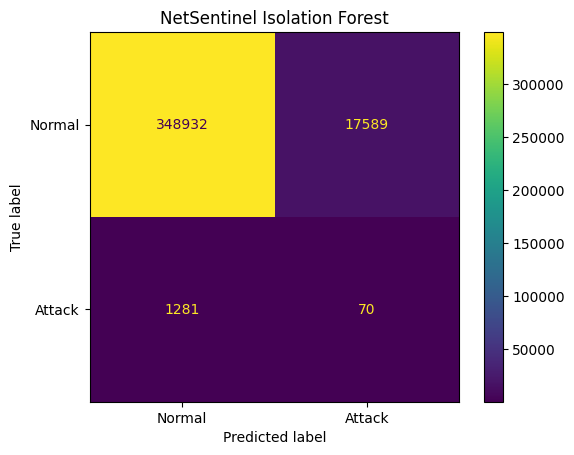

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    test_pred_binary
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Attack"
    ]
)

disp.plot()

plt.title(
    "NetSentinel Isolation Forest"
)

plt.show()

In [29]:
test_results = test_df.copy()

test_results["predicted_attack"] = test_pred_binary

test_results["anomaly_score"] = model.decision_function(
    X_test_scaled
)

In [30]:
attack_results = []

for attack_type in test_results[
    test_results[LABEL_COLUMN] == 1
]["label_name"].dropna().unique():

    subset = test_results[
        test_results["label_name"] == attack_type
    ]

    detected = subset["predicted_attack"].sum()

    detection_rate = (
        detected / len(subset)
        if len(subset) > 0
        else 0
    )

    attack_results.append({
        "attack_type": attack_type,
        "samples": len(subset),
        "detected": int(detected),
        "detection_rate": detection_rate
    })

attack_results_df = pd.DataFrame(
    attack_results
)

attack_results_df

,attack_type,samples,detected,detection_rate
0,Exploits,1100,53,0.048182
1,Denial of Service,171,9,0.052632
2,Generic,36,0,0.000000
3,Shellcode,37,5,0.135135
4,Worms,7,3,0.428571


In [31]:
import joblib
import json
from datetime import datetime, timezone

# Save trained Isolation Forest
joblib.dump(
    model,
    "isolation_forest.pkl"
)

# Save fitted scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

# Save feature configuration
schema = {
    "feature_names": FEATURE_NAMES,
    "window_size_seconds": 5,
    "model": "IsolationForest",
    "n_estimators": 200,
    "contamination": "auto",
    "random_state": 42,
    "training_rows": int(len(X_train)),
    "training_samples_used": int(len(X_train_model)),
    "created_at": datetime.now(timezone.utc).isoformat()
}

with open("feature_schema.json", "w") as f:
    json.dump(schema, f, indent=4)

print("Saved successfully:")
print("✓ isolation_forest.pkl")
print("✓ scaler.pkl")
print("✓ feature_schema.json")

Saved successfully:
✓ isolation_forest.pkl
✓ scaler.pkl
✓ feature_schema.json


In [32]:
import os

for filename in [
    "isolation_forest.pkl",
    "scaler.pkl",
    "feature_schema.json"
]:
    print(
        filename,
        "→",
        f"{os.path.getsize(filename) / 1024 / 1024:.2f} MB"
    )

isolation_forest.pkl → 1.17 MB
scaler.pkl → 0.00 MB
feature_schema.json → 0.00 MB


In [33]:
from google.colab import files

files.download("isolation_forest.pkl")
files.download("scaler.pkl")
files.download("feature_schema.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>